## Load Sentinel Packages

In [1]:
#Import libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import odc.stac
import pystac_client
from odc.stac import load
from pystac.client import Client


## Define the study AOI

In [50]:
#Yalelevu AOI imported from asset

aoi = gpd.read_file("/home/jovyan/Soil moisture-Individual Project/Ba.geojson")
aoi = aoi.to_crs("EPSG:4326")
min_lon, min_lat, max_lon, max_lat = aoi.total_bounds

bbox = [min_lon, min_lat, max_lon, max_lat]

In [51]:
#Display Map
aoi.explore()

## Load Sentinel 1 Data

1. Define the timeframe

In [52]:
catalog = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalog)
datetime = "2024-07-01/2025-06-30"

2. Load the sentinel 1 collection

In [53]:
items = client.search(
    collections=["sentinel-1-grd"],
    bbox=bbox,
    datetime=datetime,
    query={
        "sar:instrument_mode": {"eq": "IW"},
        "sat:orbit_state": {"eq": "ascending"},
        "s1:orbit_source": {"eq": "RESORB"}
    }
).item_collection()

In [54]:
items

3. Loading the VV polarization

In [55]:
ds = odc.stac.load(
items,
bands=["vv", "vh"],
bbox=bbox,
chunks={}
)

In [56]:
print(ds)

<xarray.Dataset> Size: 142MB
Dimensions:      (latitude: 1210, longitude: 976, time: 30)
Coordinates:
  * latitude     (latitude) float64 10kB -17.44 -17.44 -17.44 ... -17.56 -17.56
  * longitude    (longitude) float64 8kB 177.6 177.6 177.6 ... 177.7 177.7 177.7
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 240B 2024-07-06T06:40:45.004848 ... 20...
Data variables:
    vv           (time, latitude, longitude) uint16 71MB dask.array<chunksize=(1, 1210, 976), meta=np.ndarray>
    vh           (time, latitude, longitude) uint16 71MB dask.array<chunksize=(1, 1210, 976), meta=np.ndarray>


In [57]:
# Extract VV backscatter
# Soil moisture studies
# commonly use VV polarization
# ---------------------------
vv = ds["vv"]

4. CONVERT TO dB

In [58]:
# Sentinel-1 backscatter is often analysed in dB.
# Avoid taking log of zero values.
# -----------------------------------------------------------------------------
vv_db = 10 * np.log10(vv.where(vv > 0))

Original vv_mean stats: 16.142656326293945 38.084373474121094 22.2858829498291

Trying scale factors: (value / factor) => linear_range => dB_range
 /    1: linear min/max/mean = 16.142656/38.084373/22.285883; dB min/max/mean = 12.08/15.81/13.46
 /   10: linear min/max/mean = 1.614266/3.808437/2.228588; dB min/max/mean = 2.08/5.81/3.46
 /  100: linear min/max/mean = 0.161427/0.380844/0.222859; dB min/max/mean = -7.92/-4.19/-6.54
 / 1000: linear min/max/mean = 0.016143/0.038084/0.022286; dB min/max/mean = -17.92/-14.19/-16.54
 /10000: linear min/max/mean = 0.001614/0.003808/0.002229; dB min/max/mean = -27.92/-24.19/-26.54

Heuristic chosen_factor: 100
Using factor = 100

After conversion:
linear min/max/mean: 0.08450980484485626 0.39243829250335693 0.22285883128643036
dB min/max/mean: -10.730929374694824 -4.062286376953125 -6.544075012207031
Candidate water pixels (before cleanup): 0
No water found using dB threshold; trying linear threshold instead.
Candidate water pixels (linear test):

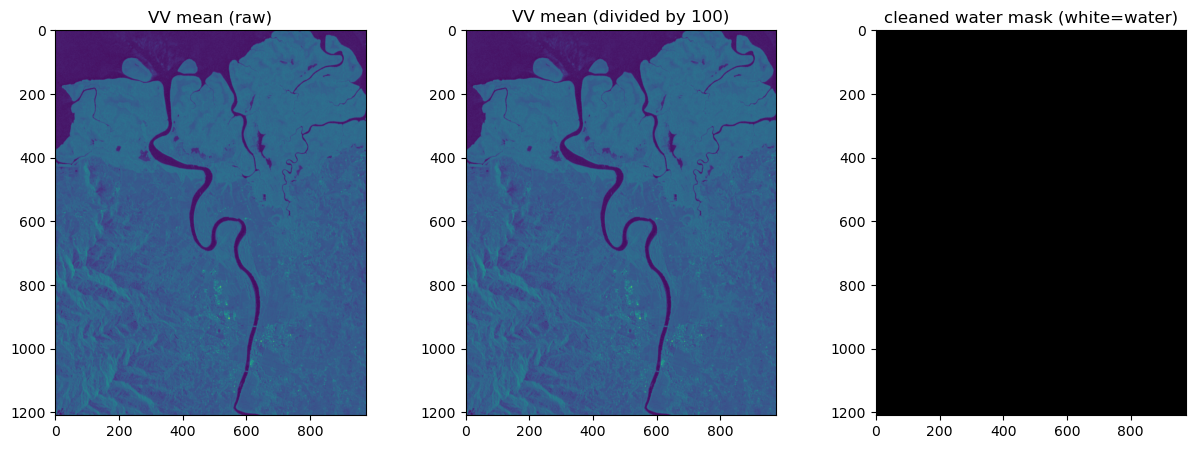

Final water pixels: 0


In [87]:
import numpy as np
import xarray as xr
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

# vv_db: your DataArray (the one you plotted earlier)
vv_mean = vv_db.mean(dim='time', skipna=True)

print("Original vv_mean stats:", float(vv_mean.min()), float(vv_mean.max()), float(vv_mean.mean()))

# Try common scale factors and show what the resulting linear/dB stats would be
candidates = [1, 10, 100, 1000, 10000]
print("\nTrying scale factors: (value / factor) => linear_range => dB_range")
for f in candidates:
    lin = vv_mean / f
    # ignore non-positive before dB conversion
    lin_pos = lin.where(lin > 0)
    db = 10 * np.log10(lin_pos)
    print(f" /{f:5d}: linear min/max/mean = {float(np.nanmin(lin_pos)):.6f}/{float(np.nanmax(lin_pos)):.6f}/{float(np.nanmean(lin_pos)):.6f}; dB min/max/mean = {float(np.nanmin(db)) if not np.isnan(np.nanmin(db)) else np.nan:.2f}/{float(np.nanmax(db)) if not np.isnan(np.nanmax(db)) else np.nan:.2f}/{float(np.nanmean(db)) if not np.isnan(np.nanmean(db)) else np.nan:.2f}")

# Heuristic: pick first factor that yields linear median between 0 and 1 (and dB in -40..0)
chosen_factor = None
for f in candidates:
    lin = vv_mean / f
    lin_median = float(np.nanmedian(lin))
    db = 10*np.log10(lin.where(lin>0))
    db_median = float(np.nanmedian(db.where(np.isfinite(db))))
    if 0.0 < lin_median < 1.0 and -40 < db_median < 0:
        chosen_factor = f
        break

print("\nHeuristic chosen_factor:", chosen_factor)

# If none chosen automatically, pick 1000 as a reasonable default if values are large:
if chosen_factor is None:
    if float(vv_mean.mean()) > 5:
        chosen_factor = 1000
    else:
        chosen_factor = 1
print("Using factor =", chosen_factor)

# Convert to linear (0..1) and compute dB
vv_linear = vv_db / chosen_factor
vv_db_recomputed = 10 * np.log10(vv_linear.where(vv_linear > 0))

# Show new stats
print("\nAfter conversion:")
print("linear min/max/mean:", float(vv_linear.min()), float(vv_linear.max()), float(vv_linear.mean()))
print("dB min/max/mean:", float(vv_db_recomputed.min()), float(vv_db_recomputed.max()), float(vv_db_recomputed.mean()))

# Choose thresholds (you can tune these)
linear_thresh = 0.04   # typical linear water threshold
db_thresh = -17.0     # typical dB water threshold

# Build mask: use dB threshold (safer after conversion)
vv_mean_db = 10 * np.log10(vv_mean/ chosen_factor)
water_candidate = vv_mean_db < db_thresh

print("Candidate water pixels (before cleanup):", int(water_candidate.sum().values))

# If none found, fall back to linear threshold
if int(water_candidate.sum().values) == 0:
    print("No water found using dB threshold; trying linear threshold instead.")
    water_candidate = (vv_mean / chosen_factor) < linear_thresh
    print("Candidate water pixels (linear test):", int(water_candidate.sum().values))

# Clean small components only if we actually have some candidate pixels
if int(water_candidate.sum().values) > 0:
    mask_arr = water_candidate.values.astype(bool)
    labels, n = ndi.label(mask_arr)
    print("connected components:", n)
    if n > 0:
        sizes = ndi.sum(mask_arr, labels, range(1, n+1))
        min_pixels = 20  # reduce to a small number while tuning
        keep_labels = np.where(sizes >= min_pixels)[0] + 1
        clean_mask = np.isin(labels, keep_labels)
    else:
        clean_mask = mask_arr
else:
    clean_mask = np.zeros_like(water_candidate.values, dtype=bool)

clean_mask_da = xr.DataArray(clean_mask, coords=water_candidate.coords, dims=water_candidate.dims, name='water_mask')

# Quick visual diagnostics
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(vv_mean.values, cmap='viridis')
ax[0].set_title('VV mean (raw)')
ax[1].imshow((vv_mean / chosen_factor).values, cmap='viridis')
ax[1].set_title(f'VV mean (divided by {chosen_factor})')
ax[2].imshow(clean_mask_da.values, cmap='gray')
ax[2].set_title('cleaned water mask (white=water)')
plt.show()

print("Final water pixels:", int(clean_mask_da.sum().values))

## Apply Water Mask

In [67]:
# Water generally has very low VV backscatterz
# Threshold may need adjustment for your AOI.
# Typical values: -18 dB to -15 dB
water_mask = vv_db.mean(dim="time") > -17

In [68]:
# Keep only non-water pixels
vv_db_land = vv_db.where(water_mask)

## DETERMINE DRY  and WET DIFFERENCE CONDITION

1. Dry Difference

In [69]:
# Lowest VV value during study period.
vv_dry = vv_db_land.min(dim="time")

2. Wet Difference

In [70]:
vv_wet = vv_db_land.max(dim="time")

## Calculate Soil Moisture Index

In [71]:
# SMI = (VV - VVdry) / (VVwet - VVdry)
# Values near 0 = Dry
# Values near 1 = Wet
# -----------------------------------------------------------------------------
smi = (vv_db_land - vv_dry) / (vv_wet - vv_dry)

In [72]:
# 14. CLIP SMI VALUES TO 0-1 RANGE
smi = smi.clip(min=0, max=1)

In [73]:
#CALCULATE ANNUAL AVERAGE SOIL MOISTURE
smi_mean = smi.mean(dim="time")

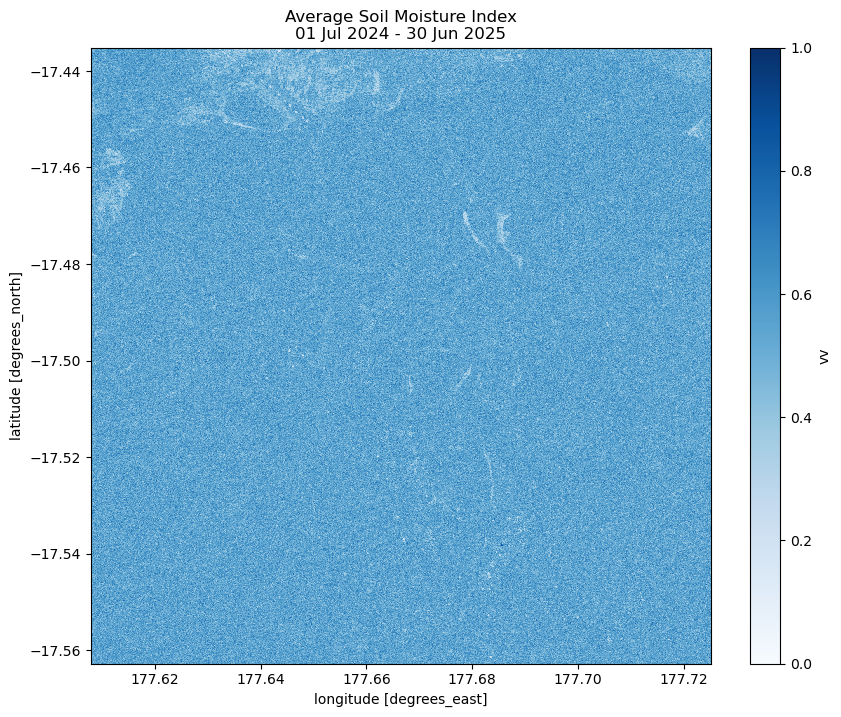

In [74]:
# DISPLAY AVERAGE SOIL MOISTURE MAP
plt.figure(figsize=(10, 8))
smi_mean.plot(
cmap="Blues",
vmin=0,
vmax=1
)
plt.title(
"Average Soil Moisture Index\n"
"01 Jul 2024 - 30 Jun 2025"
)
plt.show()

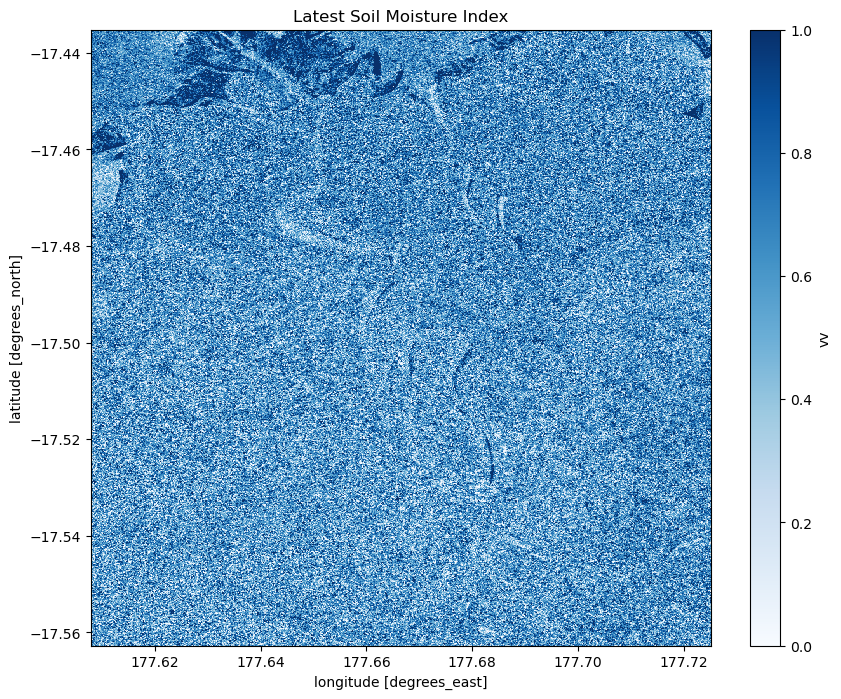

In [75]:
# 17. DISPLAY MOST RECENT SOIL MOISTURE MAP
# -----------------------------------------------------------------------------

smi_latest = smi.isel(time=-1)
plt.figure(figsize=(10, 8))
smi_latest.plot(
cmap="Blues",
vmin=0,
vmax=1
)
plt.title("Latest Soil Moisture Index")
plt.show()